In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/chili_dataset"

Mounted at /content/drive


In [2]:
import os
print(os.listdir(DATASET_PATH))

['green_chili', 'red_chili', 'Untitled0.ipynb']


In [3]:
import os

red_path = os.path.join(DATASET_PATH, "red_chili")
green_path = os.path.join(DATASET_PATH, "green_chili")

print("Red Chili:", len(os.listdir(red_path)))
print("Green Chili:", len(os.listdir(green_path)))

Red Chili: 33
Green Chili: 33


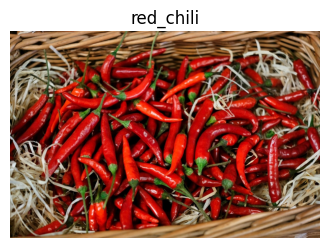

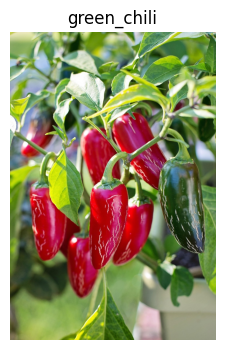

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import random

for folder in ["red_chili", "green_chili"]:
  folder_path = os.path.join(DATASET_PATH, folder)

  image_name = random.choice(os.listdir(folder_path))
  image_path = os.path.join(folder_path, image_name)

  img = Image.open(image_path)
  plt.figure(figsize=(4, 4))
  plt.imshow(img)
  plt.axis("off")
  plt.title(folder)
  plt.show()

In [5]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=42,
    validation_split=0.2,
    subset="both")

print(train_ds.class_names)
print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))

Found 66 files belonging to 2 classes.
Using 53 files for training.
Using 13 files for validation.
['green_chili', 'red_chili']
Train batches: 7
Validation batches: 2


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [7]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),])

# MobileNetV2 laden
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights="imagenet")

base_model.trainable = False

# Modell aufbauen
model = models.Sequential([data_augmentation,
                           layers.Rescaling(1./255),
                           base_model,
                           layers.GlobalAveragePooling2D(),
                           layers.Dropout(0.2),
                           layers.Dense(1, activation="sigmoid")])

# Kompilieren
model.compile(optimizer="adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])

# Modellübersicht
model.summary()

# Training
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7358 - loss: 0.5905 - val_accuracy: 0.6923 - val_loss: 0.5514
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7547 - loss: 0.4721 - val_accuracy: 0.7692 - val_loss: 0.4744
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8679 - loss: 0.3702 - val_accuracy: 0.7692 - val_loss: 0.4381
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.9057 - loss: 0.3067 - val_accuracy: 0.8462 - val_loss: 0.4203
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.9245 - loss: 0.2904 - val_accuracy: 0.8462 - val_loss: 0.3994
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.9434 - loss: 0.2633 - val_accuracy: 0.8462 - val_loss: 0.3842
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9623 - loss: 0.2068 - val_accuracy: 0.7692 - val_loss: 0.3643
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9057 - loss: 0.2145 - val_accuracy: 0.7692 - val_loss: 0.3

Das Modell erreichte auf den Validierungsdaten eine Genauigkeit von bis zu 92,3 %.

In [12]:
model.save("chili_classifier.keras")

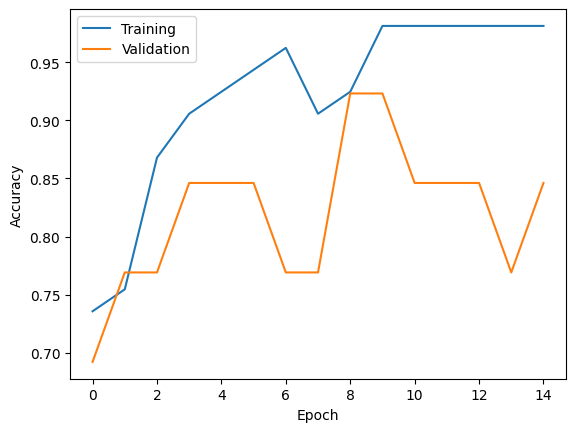

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Das Modell wurde mittels Transfer Learning mit MobileNetV2 trainiert und erreichte auf den Validierungsdaten eine Genauigkeit von bis zu 92,3 %.

In [14]:
model.save("chili_classifier.keras")

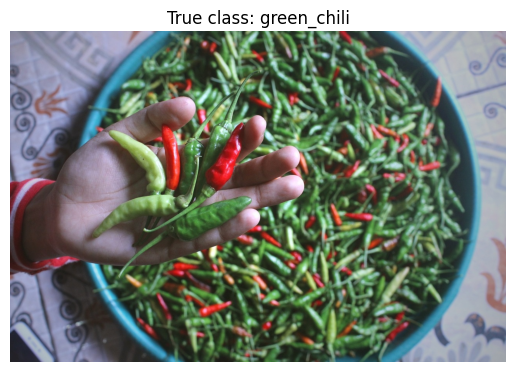

Prediction score: 0.37776318
Actual:    green_chili
Predicted: green_chili
Score:     0.3778


In [15]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

class_name = random.choice(["red_chili", "green_chili"])

folder = os.path.join(DATASET_PATH, class_name)
image_name = random.choice(os.listdir(folder))
image_path = os.path.join(folder, image_name)

img = Image.open(image_path)

plt.imshow(img)
plt.title(f"True class: {class_name}")
plt.axis("off")
plt.show()

# Bild für MobileNetV2 vorbereiten und vorhersagen
img = Image.open(image_path).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array, verbose=0)[0][0]

print("Prediction score:", prediction)

# Klasse bestimmen
predicted_class = "red_chili" if prediction > 0.5 else "green_chili"

print("Actual:   ", class_name)
print("Predicted:", predicted_class)
print("Score:    ", round(float(prediction), 4))


In [16]:
import random
import numpy as np
from PIL import Image
import os

correct = 0
total = 20

for _ in range(total):
    true_class = random.choice(["red_chili", "green_chili"])

    folder = os.path.join(DATASET_PATH, true_class)
    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    score = model.predict(img_array, verbose=0)[0][0]

    pred_class = "red_chili" if score > 0.5 else "green_chili"

    if pred_class == true_class:
        correct += 1

    print(
        f"True: {true_class:12} "
        f"Pred: {pred_class:12} "
        f"Score: {score:.3f}"
    )

print(f"\nAccuracy: {correct}/{total} = {correct/total:.1%}")

True: red_chili    Pred: green_chili  Score: 0.375
True: green_chili  Pred: green_chili  Score: 0.379
True: green_chili  Pred: green_chili  Score: 0.378
True: green_chili  Pred: green_chili  Score: 0.377
True: green_chili  Pred: green_chili  Score: 0.364
True: red_chili    Pred: green_chili  Score: 0.364
True: green_chili  Pred: green_chili  Score: 0.376
True: red_chili    Pred: green_chili  Score: 0.373
True: green_chili  Pred: green_chili  Score: 0.378
True: green_chili  Pred: green_chili  Score: 0.367
True: green_chili  Pred: green_chili  Score: 0.365
True: green_chili  Pred: green_chili  Score: 0.378
True: red_chili    Pred: green_chili  Score: 0.364
True: green_chili  Pred: green_chili  Score: 0.368
True: red_chili    Pred: green_chili  Score: 0.373
True: green_chili  Pred: green_chili  Score: 0.367
True: green_chili  Pred: green_chili  Score: 0.399
True: green_chili  Pred: green_chili  Score: 0.367
True: red_chili    Pred: green_chili  Score: 0.372
True: green_chili  Pred: green_

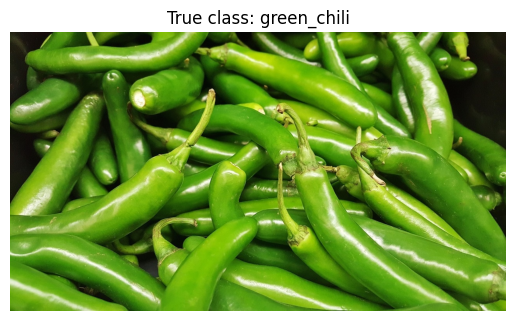

Prediction score: 0.046696175
Actual:    green_chili
Predicted: green_chili
Score:     0.0467


In [18]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

class_name = random.choice(["red_chili", "green_chili"])

folder = os.path.join(DATASET_PATH, class_name)
image_name = random.choice(os.listdir(folder))
image_path = os.path.join(folder, image_name)

img = Image.open(image_path)

plt.imshow(img)
plt.title(f"True class: {class_name}")
plt.axis("off")
plt.show()

# Bild für MobileNetV2 vorbereiten und vorhersagen
img = Image.open(image_path).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0][0]

print("Prediction score:", prediction)

# Klasse bestimmen
predicted_class = "red_chili" if prediction > 0.5 else "green_chili"

print("Actual:   ", class_name)
print("Predicted:", predicted_class)
print("Score:    ", round(float(prediction), 4))


In [19]:
import random
import numpy as np
from PIL import Image
import os

correct = 0
total = 20

for _ in range(total):

    true_class = random.choice(["red_chili", "green_chili"])

    folder = os.path.join(DATASET_PATH, true_class)
    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    score = model.predict(img_array, verbose=0)[0][0]

    pred_class = "red_chili" if score > 0.5 else "green_chili"

    if pred_class == true_class:
        correct += 1

    print(
        f"True: {true_class:12} | "
        f"Pred: {pred_class:12} | "
        f"Score: {score:.3f}"
    )

print(f"\nAccuracy: {correct}/{total} = {correct/total:.1%}")

True: red_chili    | Pred: green_chili  | Score: 0.487
True: red_chili    | Pred: red_chili    | Score: 0.576
True: red_chili    | Pred: red_chili    | Score: 0.983
True: red_chili    | Pred: red_chili    | Score: 0.981
True: green_chili  | Pred: green_chili  | Score: 0.169
True: red_chili    | Pred: red_chili    | Score: 0.920
True: green_chili  | Pred: green_chili  | Score: 0.121
True: red_chili    | Pred: red_chili    | Score: 0.967
True: green_chili  | Pred: green_chili  | Score: 0.025
True: red_chili    | Pred: red_chili    | Score: 0.965
True: green_chili  | Pred: green_chili  | Score: 0.023
True: green_chili  | Pred: green_chili  | Score: 0.104
True: red_chili    | Pred: red_chili    | Score: 0.906
True: green_chili  | Pred: green_chili  | Score: 0.006
True: green_chili  | Pred: green_chili  | Score: 0.010
True: green_chili  | Pred: green_chili  | Score: 0.045
True: green_chili  | Pred: green_chili  | Score: 0.059
True: green_chili  | Pred: green_chili  | Score: 0.112
True: gree

In [22]:
model.save("chili_classifier.keras")

In [23]:
model.save("/content/drive/MyDrive/Colab Notebooks/chili_dataset/chili_classifier.keras")


## Aufgabe 2 - Dataset laden

Legen Sie eine `ImageFolder`-Struktur an und laden Sie die Bilder mit Resize, ToTensor und Normalisierung.

In [26]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])])

dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

# Klassen prüfen
print(dataset.classes)

# Bilderanzahl prüfen
print("Anzahl Bilder:", len(dataset))

# DataLoader erstellen
loader = DataLoader(dataset,
                    batch_size=8,
                    shuffle=True)

# Erste Batch testen
images, labels = next(iter(loader))

print(images.shape)
print(labels)

['green_chili', 'red_chili']
Anzahl Bilder: 66
torch.Size([8, 3, 224, 224])
tensor([0, 0, 0, 0, 1, 1, 0, 1])


Die Bilder wurden in einer ImageFolder-Struktur organisiert und mit torchvision.datasets.ImageFolder geladen. Dabei wurden alle Bilder auf eine Größe von 224×224 Pixeln skaliert, in Tensoren umgewandelt und normalisiert. Anschließend wurden die Daten mit einem DataLoader in Batches der Größe 8 bereitgestellt.

## Aufgabe 3 - Scratch-Modell

Trainieren Sie ein kleines CNN von Scratch. Dokumentieren Sie, ob es overfittet.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,792,609 (10.65 MB)

 Trainable params: 2,792,609 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 738ms/step - accuracy: 0.6981 - loss: 0.5970 - val_accuracy: 0.8462 - val_loss: 0.2815
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9057 - loss: 0.2849 - val_accuracy: 0.7692 - val_loss: 0.3574
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.8302 - loss: 0.3468 - val_accuracy: 0.6923 - val_loss: 0.7961
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9434 - loss: 0.1665 - val_accuracy: 0.8462 - val_loss: 0.2436
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.9434 - loss: 0.1250 - val_accuracy: 0.9231 - val_loss: 0.1795
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.9623 - loss: 0.0857 - val_accuracy: 0.9231 - val_loss: 0.2130
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 1.0000 - loss: 0.0354 - val_accuracy: 0.9231 - val_loss: 0.1382
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9811 - loss: 0.0899 - val_accuracy: 0.9231 - val_loss: 0

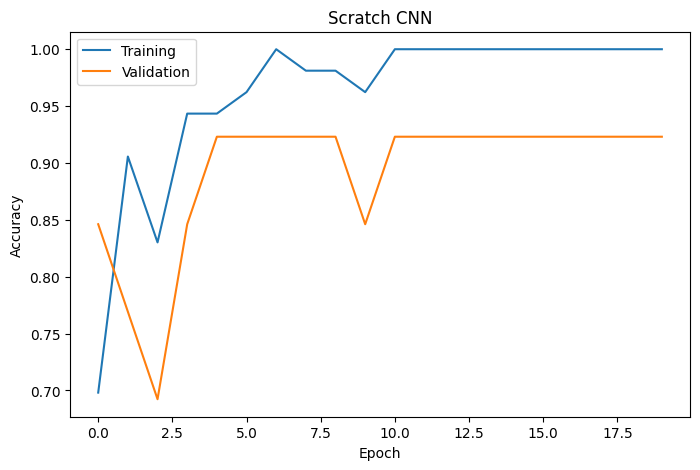

In [27]:
# Scratch-CNN
from tensorflow.keras import layers, models

scratch_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

scratch_model.summary()

# Komplilieren
scratch_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# Trainieren
scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# Accuracy darstellen
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    scratch_history.history["accuracy"],
    label="Training"
)

plt.plot(
    scratch_history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Scratch CNN")
plt.legend()
plt.show()

Das Scratch-CNN erreichte nach wenigen Epochen eine Trainingsgenauigkeit von 100 %. Die Validierungsgenauigkeit stabilisierte sich dagegen bei etwa 92,3 %. Gleichzeitig stieg der Validation Loss zum Ende des Trainings an. Dies deutet auf leichtes Overfitting hin. Das Modell lernt die Trainingsdaten nahezu perfekt, erzielt auf bisher unbekannten Bildern jedoch keine weiteren Verbesserungen.

Trotz der geringen Datensatzgröße erzielte das Scratch-CNN ähnliche Genauigkeitswerte wie das Transfer-Learning-Modell. Aufgrund der kleinen Validierungsmenge von 13 Bildern sind die Ergebnisse jedoch nur eingeschränkt aussagekräftig.

## Aufgabe 4 - Transfer Learning

Laden Sie ein vortrainiertes ResNet18, frieren Sie Features ein, ersetzen Sie den Head und trainieren Sie nur den Head.

In [29]:
#ResNet18 laden
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Features einfrieren
for param in model.parameters():
    param.requires_grad = False

# Head ersetzen
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

# Prüfen
print(model.fc)

# Gerät wählen
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

model = model.to(device)

# Loss und Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

#Trainingsschleife

num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Loss: {running_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Linear(in_features=512, out_features=2, bias=True)
cuda
Epoch 1/10 Loss: 6.8925 Accuracy: 46.97%
Epoch 2/10 Loss: 5.6209 Accuracy: 62.12%
Epoch 3/10 Loss: 4.9023 Accuracy: 69.70%
Epoch 4/10 Loss: 5.2856 Accuracy: 69.70%
Epoch 5/10 Loss: 4.6208 Accuracy: 72.73%
Epoch 6/10 Loss: 4.1984 Accuracy: 84.85%
Epoch 7/10 Loss: 3.1175 Accuracy: 87.88%
Epoch 8/10 Loss: 2.8830 Accuracy: 90.91%
Epoch 9/10 Loss: 5.3401 Accuracy: 69.70%
Epoch 10/10 Loss: 3.7448 Accuracy: 83.33%


Für das Transfer Learning wurde ein vortrainiertes ResNet18 verwendet. Alle vortrainierten Feature-Extraktionsschichten wurden eingefroren. Der ursprüngliche Klassifikationskopf wurde durch eine neue Fully-Connected-Schicht mit zwei Ausgängen ersetzt. Anschließend wurde ausschließlich der neue Head trainiert. Während des Trainings stieg die Genauigkeit zeitweise auf etwa 91 %. Aufgrund der geringen Größe des Datensatzes zeigten sich jedoch deutliche Schwankungen zwischen den Epochen.

## Aufgabe 5 - Fine-Tuning

Geben Sie den letzten Block frei und trainieren Sie mit kleiner Lernrate weiter.

In [30]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


Für das Fine-Tuning wurde der letzte ResNet18-Block (layer4) zusammen mit dem Klassifikationskopf freigegeben. Alle früheren Schichten blieben eingefroren. Anschließend wurde das Modell mit einer kleinen Lernrate von 0.00001 weitertrainiert, um die vortrainierten Merkmale an den Chili-Datensatz anzupassen.

## Aufgabe 6 - Eigene Testbilder

Nehmen Sie neue Bilder auf, die nicht im Training waren. Zeigen Sie Bild, echte Klasse, Vorhersage und Wahrscheinlichkeit.

In [47]:
import os

for root, dirs, files in os.walk(
    "/content/drive/MyDrive/Colab Notebooks/chili_dataset"
):
    if files:
        print(root)
        for f in files:
            print("   ", f)

/content/drive/MyDrive/Colab Notebooks/chili_dataset
    Chili_Classifier.ipynb
    chili_classifier.keras
/content/drive/MyDrive/Colab Notebooks/chili_dataset/green_chili
    green_001.jpg
    green_002.jpg
    green_003.jpg
    green_004.jpg
    green_005.jpg
    green_006.jpg
    green_007.jpg
    green_008.jpg
    green_009.jpg
    green_010.jpg
    green_011.jpg
    green_012.jpg
    green_013.jpg
    green_014.jpg
    green_015.jpg
    green_016.jpg
    green_017.jpg
    green_018.jpg
    green_019.jpg
    green_020.jpg
    green_021.jpg
    green_022.jpg
    green_023.jpg
    green_025.jpg
    green_026.jpg
    green_027.jpg
    green_028.jpg
    green_029.jpg
    green_030.jpg
    green_031.jpg
    green_032.jpg
    green_033.jpg
    green_024.jpg
/content/drive/MyDrive/Colab Notebooks/chili_dataset/red_chili
    red_001.jpg
    red_002.jpg
    red_003.jpg
    red_004.jpg
    red_005.jpg
    red_006.jpg
    red_007.jpg
    red_008.jpg
    red_009.jpg
    red_010.jpg
    red_011

In [49]:
from tensorflow import keras

tf_model = keras.models.load_model(
    "/content/drive/MyDrive/Colab Notebooks/chili_dataset/chili_classifier.keras"
)

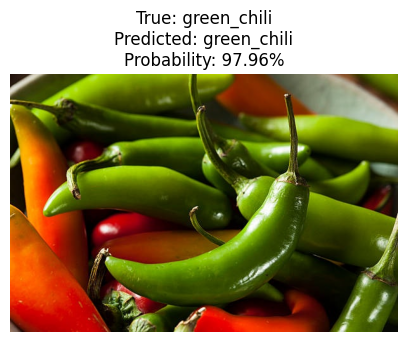

Datei: green_test_01.jpg
True class: green_chili
Predicted: green_chili
Probability: 97.96%
--------------------------------------------------


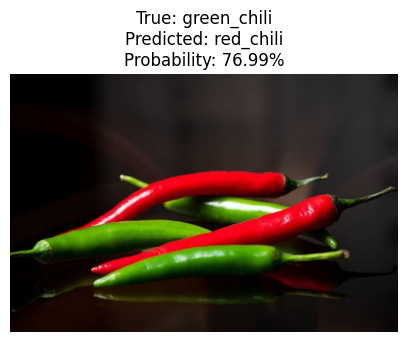

Datei: green_test_02.jpg
True class: green_chili
Predicted: red_chili
Probability: 76.99%
--------------------------------------------------


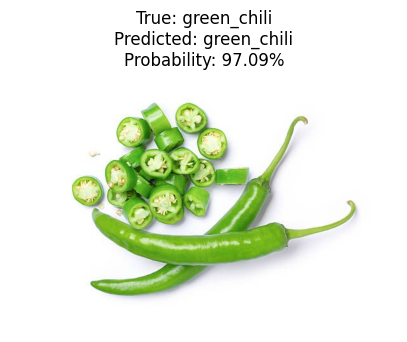

Datei: green_test_03.jpg
True class: green_chili
Predicted: green_chili
Probability: 97.09%
--------------------------------------------------


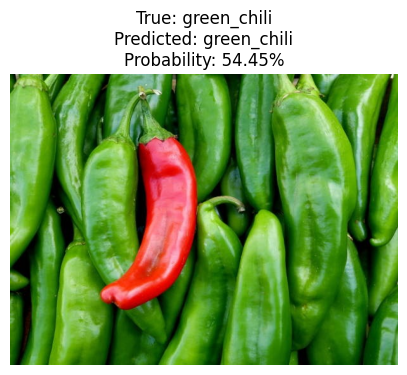

Datei: green_test_04.jpg
True class: green_chili
Predicted: green_chili
Probability: 54.45%
--------------------------------------------------


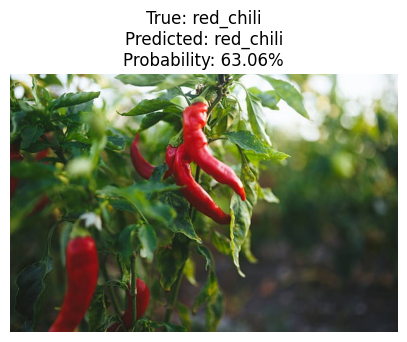

Datei: red_test_01.jpg
True class: red_chili
Predicted: red_chili
Probability: 63.06%
--------------------------------------------------


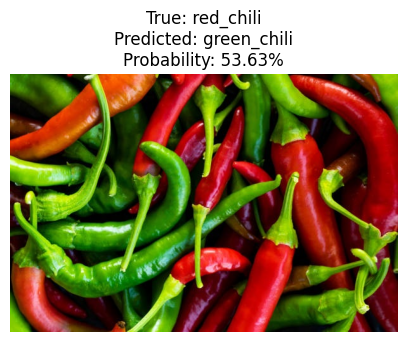

Datei: red_test_02.jpg
True class: red_chili
Predicted: green_chili
Probability: 53.63%
--------------------------------------------------


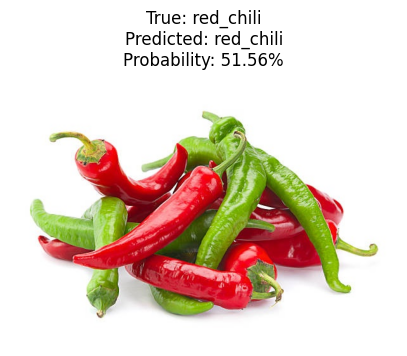

Datei: red_test_03.jpg
True class: red_chili
Predicted: red_chili
Probability: 51.56%
--------------------------------------------------


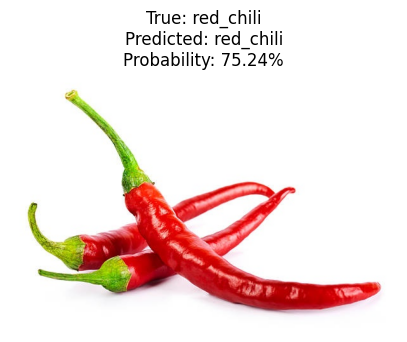

Datei: red_test_04.jpg
True class: red_chili
Predicted: red_chili
Probability: 75.24%
--------------------------------------------------


In [51]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

TEST_PATH = "/content/drive/MyDrive/Colab Notebooks/chili_dataset/test_images"

for filename in sorted(os.listdir(TEST_PATH)):

    image_path = os.path.join(TEST_PATH, filename)

    if filename.startswith("red"):
        true_class = "red_chili"
    elif filename.startswith("green"):
        true_class = "green_chili"
    else:
        true_class = "unknown"

    img = Image.open(image_path).convert("RGB")

    img_resized = img.resize((224, 224))

    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    score = tf_model.predict(img_array, verbose=0)[0][0]

    predicted_class = (
        "red_chili"
        if score > 0.5
        else "green_chili"
    )

    probability = (
        score if score > 0.5
        else 1 - score
    )

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Probability: {probability:.2%}"
    )
    plt.show()

    print("Datei:", filename)
    print("True class:", true_class)
    print("Predicted:", predicted_class)
    print("Probability:", f"{probability:.2%}")
    print("-" * 50)

**green_test_01.jpg** : Wahrscheinlichkeit: 97.96%

**green_test_02.jpg** : Probability: 76.99%
  - Analyse:
     - Auf dem Bild sind sehr auffällige rote Chilis sichtbar
     - Die roten Chilis liegen im Vordergrund und dominieren große Bildbereiche
     - Im Trainingsdatensatz war die Klassenzuordnung vermutlich oft stark an die dominante Farbe gekoppelt

**green_test_03.jpg** : Probability: 97.09%
  - mehrere grüne Chili-Scheiben
  - zwei ganze grüne Chilis
  - heller, neutraler Hintergrund
  - keine roten Chilis sichtbar

**green_test_04.jpg** : 54.45%
  - Die rote Chili beeinflusst die Entscheidung offenbar stark. Das Modell erkennt zwar, dass überwiegend grüne Chilis vorhanden sind, aber die einzelne rote Chili sorgt für Unsicherheit

**red_test_01.jpg** : 63.06%
  - mehrere rote Chilis an einer Pflanze
  - viele grüne Blätter
  - natürlichen Hintergrund
  - keine isolierte Darstellung der Früchte

Ein großer Teil des Bildes besteht aus grünen Blättern.
Die roten Chilis nehmen nur einen Teil der Bildfläche ein.
Das Bild ähnelt damit eher einer natürlichen Szene als einem typischen Produktfoto

**red_test_02.jpg** : Probability: 53.63%
  - mehrere rote Chilis
  - mehrere grüne Chilis
  - dicht gepackte Anordnung
  - ähnliche Größen und Verteilung beider Farben


Das Bild wurde fälschlicherweise als green_chili klassifiziert. Die Vorhersagewahrscheinlichkeit betrug jedoch nur 53,63 %, was auf eine hohe Unsicherheit des Modells hindeutet. Das Testbild enthielt sowohl zahlreiche rote als auch grüne Chilis. Die starke Durchmischung beider Klassen erschwerte die eindeutige Zuordnung.

**red_test_03.jpg** : Probability: 51.56%
  - mehrere rote Chilis
  - mehrere grüne Chilis
  - heller Hintergrund
  - beide Farben sind ähnlich stark vertreten

Das Modell ist sehr sicher, wenn eine Farbe klar dominiert.
Das Modell wird unsicher, wenn rote und grüne Chilis gemeinsam auftreten.
Dieses Bild zeigt genau diesen Effekt:
  - viele rote Chilis → spricht für red_chili
  - viele grüne Chilis → spricht für green_chili

 **red_test_04.jpg** :  Probability: 75.24%


Zur Evaluation wurden acht neue Testbilder verwendet, die nicht Teil des Trainingsdatensatzes waren. Für jedes Bild wurden die tatsächliche Klasse, die Vorhersage des Modells sowie die Vorhersagewahrscheinlichkeit ausgegeben.
Von acht Testbildern wurden sechs korrekt klassifiziert. Dies entspricht einer Testgenauigkeit von 75 %. Die besten Ergebnisse wurden bei Bildern erzielt, die überwiegend rote bzw. grüne Chilis zeigten. Schwierigkeiten traten insbesondere bei Bildern auf, die gleichzeitig rote und grüne Chilis enthielten. In diesen Fällen war die Vorhersagewahrscheinlichkeit deutlich geringer und es kam vereinzelt zu Fehlklassifikationen.